# Extracting random samples from Xarray.DataArray <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with both the `NCI` and `DEA Sandbox` environments
* **Products used:** 
[ga_s2am_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2am_ard_3), 

## Description
A _compulsory_ description of the notebook, including a brief overview of how Digital Earth Australia helps to address the problem set out above.
It can be good to include a run-down of the tools/methods that will be demonstrated in the notebook:

1. First we do this
2. Then we do this
3. Finally we do this

***

### Load packages

Import Python packages that are used for the analysis

In [1]:
%load_ext autoreload
%autoreload 2

import datacube
import numpy as np
import xarray as xr 
import pystac_client
import planetary_computer
import matplotlib.pyplot as plt

import odc.stac
from odc.geo.geom import BoundingBox
from odc.geo.xr import assign_crs
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import sys
sys.path.insert(1, "../Tools/")
from dea_tools.validation import random_sampling

### Connect to the datacube and Planetary computer

Connect to the datacube so we can access DEA data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [7]:
#datcube
dc = datacube.Datacube(app='random_sampling')

# Open a client pointing to the Microsoft Planetary Computer data catalogue
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

### Analysis parameters

An *optional* section to inform the user of any parameters they'll need to configure to run the notebook:

* `param_name_1`: Simple description (e.g. `example_value`). Advice about appropriate values to choose for this parameter.
* `param_name_2`: Simple description (e.g. `example_value`). Advice about appropriate values to choose for this parameter.


In [14]:
# Set the central latitude and longitude
central_lat = -35.29
central_lon =  149.113

# Set the buffer to load around the central coordinates. 
buffer = 0.3

time = ("2020-01-01", "2020-12-01")

# Compute the bounding box for the study area
latitude = (central_lat - buffer, central_lat + buffer)
longitude = (central_lon - buffer, central_lon + buffer)

## Load landcover data

In [4]:
# Convert data-cube style queries into something readable by `pystac_client`
bbox = BoundingBox.from_xy(longitude, latitude)
time_range = "/".join(time)

# Search for STAC items from "esa-worldcover" product
items = catalog.search(
    collections="esa-worldcover",
    bbox=bbox,
    datetime=time_range,
).item_collection()

# Load ESA WorldCover data with odc-stac
lc = odc.stac.load(
    items,
    bbox=bbox,
    bands=["map"],
    crs="EPSG:3577",
    resolution=30,
)
lc = lc['map'].squeeze()

## Load a geomedian

In [21]:
# Lazy load our filtered data
ds = dc.load(
    product="ga_ls8cls9c_gm_cyear_3",
    time=time,
    measurements=["nbart_red", 'nbart_green', 'nbart_blue'],
    x=longitude,
    y=latitude,
    output_crs="EPSG:3577",
    resolution=(30, -30),
).squeeze()


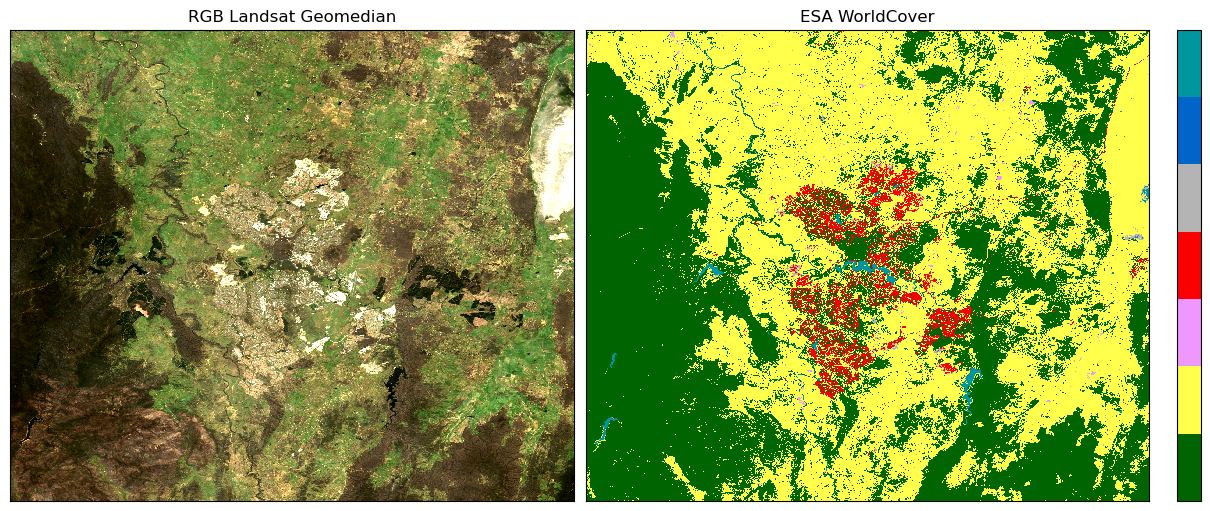

In [26]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True, layout='constrained')


ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[0], add_labels=False)
ax[0].set_title("RGB Landsat Geomedian");
ax[0].axes.get_xaxis().set_ticks([])
ax[0].axes.get_yaxis().set_ticks([])

categories =['tree=10', 'grass=30', 'crop=40', 'urban=50', 'sparse=60', 'water=80', 'wetland=90']
colours = ['#006400', '#ffff4c', '#f096ff', '#fa0000', '#b4b4b4', '#0064c8', '#0096a0']

cmap = LinearSegmentedColormap.from_list("landcover_cmap", colours, N=len(colours))
im = lc.plot(cmap=cmap, ax=ax[1], add_labels=False, add_colorbar=False)

ax[1].set_title("ESA WorldCover");
ax[1].axes.get_xaxis().set_ticks([])
ax[1].axes.get_yaxis().set_ticks([])

# axins1 = inset_axes(ax,width="70%",height="5%",loc="lower left", borderpad=2)
cbar = fig.colorbar(im, ax=ax[1], ticks=(np.arange(len(categories))+0.5)*(len(categories)-1)/(len(categories)), orientation='vertical')
# cbar.ax.set_xticklabels(categories, fontsize=9);

## Extract random samples using different sampling strategies

In [27]:
train_points_manual = random_sampling(lc, sampling='manual', manual_class_ratios={'10':100, '80':100, '50':100})

train_points_stratified_random = random_sampling(lc, sampling='stratified_random', n=400)

train_points_equal_stratified_random = random_sampling(lc, sampling='equal_stratified_random', n=400)

train_points_random = random_sampling(lc, sampling='random', n=400)

Class 10: sampling 100 points
Class 80: sampling 100 points
Class 50: sampling 100 points
Class 10: sampling 177 points
Class 30: sampling 204 points
Class 40: sampling 1 points
Class 50: sampling 13 points
Class 60: sampling 3 points
Class 80: sampling 3 points
Class 90: sampling 0 points
Class 10: sampling 58 points
Class 30: sampling 58 points
Class 40: sampling 58 points
Class 50: sampling 58 points
Class 60: sampling 58 points
Class 80: sampling 58 points
Class 90: sampling 58 points
Sampling 400 points


## Plot

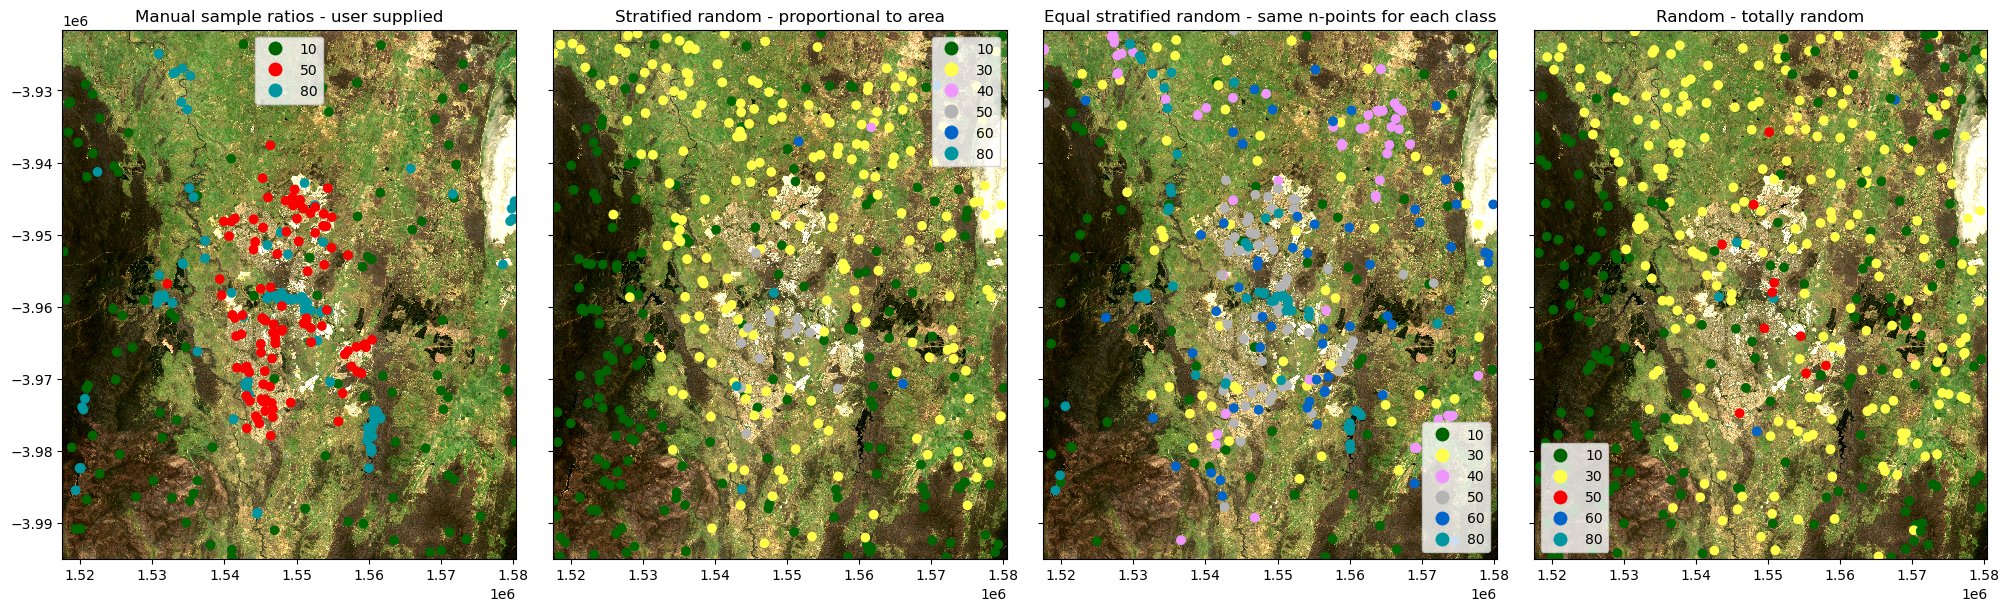

In [30]:
fig, ax = plt.subplots(1,4, figsize=(20,6), sharey=True, layout='constrained')

ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[0], add_labels=False)
train_points_manual.plot(ax=ax[0], column='class', cmap=cmap, categorical=True, legend=True)
ax[0].set_title('Manual sample ratios - user supplied')

ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[1], add_labels=False)
train_points_stratified_random.plot(ax=ax[1], column='class', cmap=cmap, categorical=True, legend=True)
ax[1].set_title('Stratified random - proportional to area')

ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[2], add_labels=False)
train_points_equal_stratified_random.plot(ax=ax[2], column='class', cmap=cmap, categorical=True, legend=True)
ax[2].set_title('Equal stratified random - same # points for each class')

ds[['nbart_red', 'nbart_green', 'nbart_blue']].to_array().plot.imshow(robust=True, ax=ax[3], add_labels=False)
train_points_random.plot(ax=ax[3], column='class', legend=True, cmap=cmap, categorical=True)
ax[3].set_title('Random - totally random');


## Test at very large scale

`>1 billion float32 pixels`

In [36]:
# Set the central latitude and longitude
central_lat = -42.0928
central_lon =  146.7220

# Set the buffer to load around the central coordinates. 
buffer = 1.6

time = ("2020-01-01", "2020-12-01")

# Compute the bounding box for the study area
latitude = (central_lat - buffer, central_lat + buffer)
longitude = (central_lon - buffer, central_lon + buffer)

In [37]:
# Convert data-cube style queries into something readable by `pystac_client`
bbox = BoundingBox.from_xy(longitude, latitude)
time_range = "/".join(time)

# Search for STAC items from "esa-worldcover" product
items = catalog.search(
    collections="esa-worldcover",
    bbox=bbox,
    datetime=time_range,
).item_collection()

# Load ESA WorldCover data with odc-stac
lc = odc.stac.load(
    items,
    bbox=bbox,
    bands=["map"],
    crs="EPSG:3577",
    resolution=10,
)
lc = lc['map'].squeeze()
lc = lc.where(lc>0)
print('total pixels =', len(lc.x)*len(lc.y))

total pixels = 1021361304


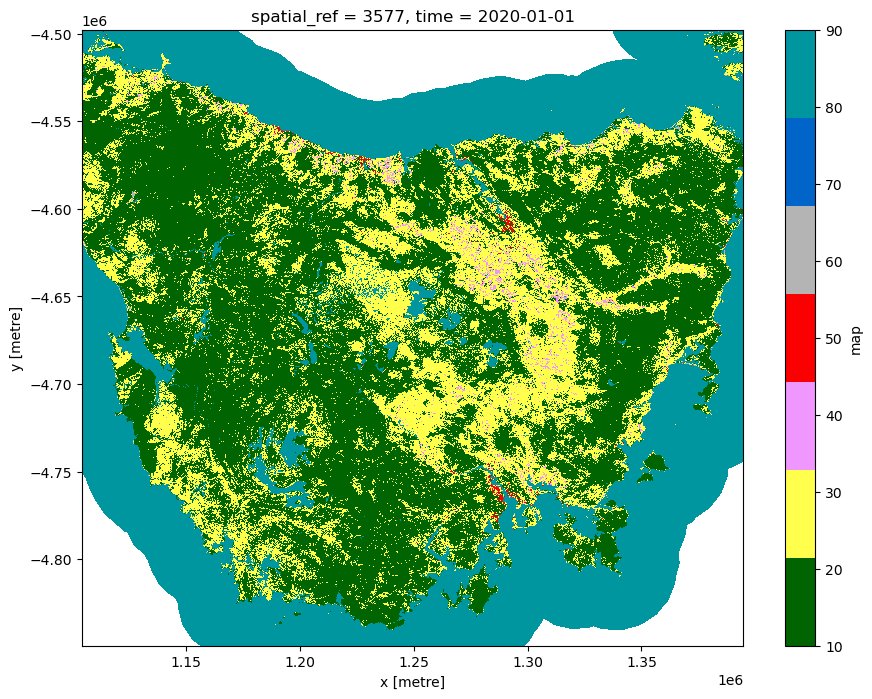

In [41]:
lc.plot.imshow(size=8, cmap=cmap)

In [42]:
%%time
train_points_equal_stratified_random = random_sampling(lc, sampling='equal_stratified_random', n=3000)

Class 10: sampling 375 points
Class 20: sampling 375 points
Class 30: sampling 375 points
Class 40: sampling 375 points
Class 50: sampling 375 points
Class 60: sampling 375 points
Class 80: sampling 375 points
Class 90: sampling 375 points
CPU times: user 2min 4s, sys: 9.79 s, total: 2min 14s
Wall time: 2min 14s


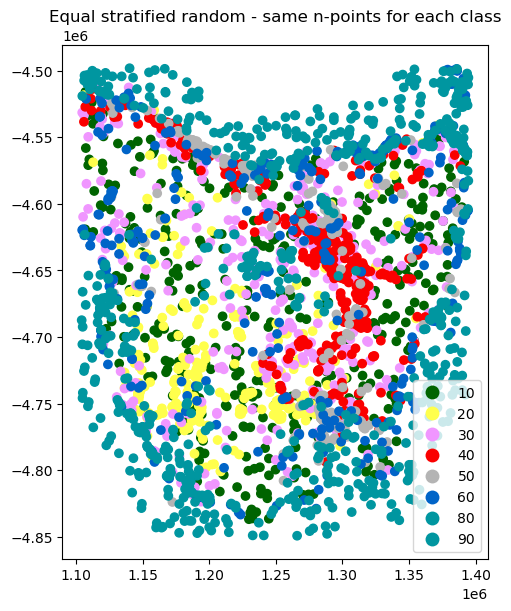

In [44]:
fig, ax = plt.subplots(1,1, figsize=(7,6), sharey=True, layout='constrained')
train_points_equal_stratified_random.plot(ax=ax, column='class', legend=True, categorical=True, cmap=cmap)
ax.set_title('Equal stratified random - same n-points for each class');

In [ ]:
# query = {
#     "time": (start_date, end_date),
# }

# # Load DEA Land Cover data from the datacube
# lc = dc.load(
#     product="ga_ls_landcover_class_cyear_3",
#     output_crs="EPSG:3577",
#     measurements=[
#         "level3",
#     ],
#     resolution=(-20, 20),
#     **query
# )
# lc = lc['level3'].squeeze()

# print('total pixels =', len(lc.x)*len(lc.y))
# lc = lc.where(lc!=255)

# %%time
# train_points_equal_stratified_random = random_sampling(lc, sampling='equal_stratified_random', n=3000)

# fig, ax = plt.subplots(1,1, figsize=(10,6), sharey=True, layout='constrained')
# train_points_equal_stratified_random.plot(ax=ax, column='class', legend=True, categorical=True, cmap='tab10')
# ax[0].set_title('Equal stratified random - same n-points for each class')

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** July 2025

**Compatible datacube version:** 

In [ ]:
print(datacube.__version__)

## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->